In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanik/Titanic.csv


In [8]:
df = pd.read_csv('/kaggle/input/titanik/Titanic.csv')

In [9]:
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [10]:

# Расшифровка столбцов датасета Titanic

# PassengerId — уникальный идентификатор пассажира
# Survived — факт выживания (0 = не выжил, 1 = выжил)
# Pclass — класс билета (1 = высший, 2 = средний, 3 = низший)
# Name — полное имя пассажира
# Sex — пол (male = мужчина, female = женщина)
# Age — возраст пассажира (в годах)
# SibSp — количество братьев/сестёр и супругов пассажира на борту
# Parch — количество родителей и детей пассажира на борту
# Ticket — номер билета
# Fare — стоимость билета (в фунтах стерлингов)
# Cabin — номер каюты (может отсутствовать)
# Embarked — порт посадки:
#         C = Шербур (Франия)
#         Q = Квинстаун (Ирлания)
#         S = Саутгемптон (Англия)


Мужчины: всего 577, выжило 109 (18.9%)
Женщины: всего 314, выжило 233 (74.2%)


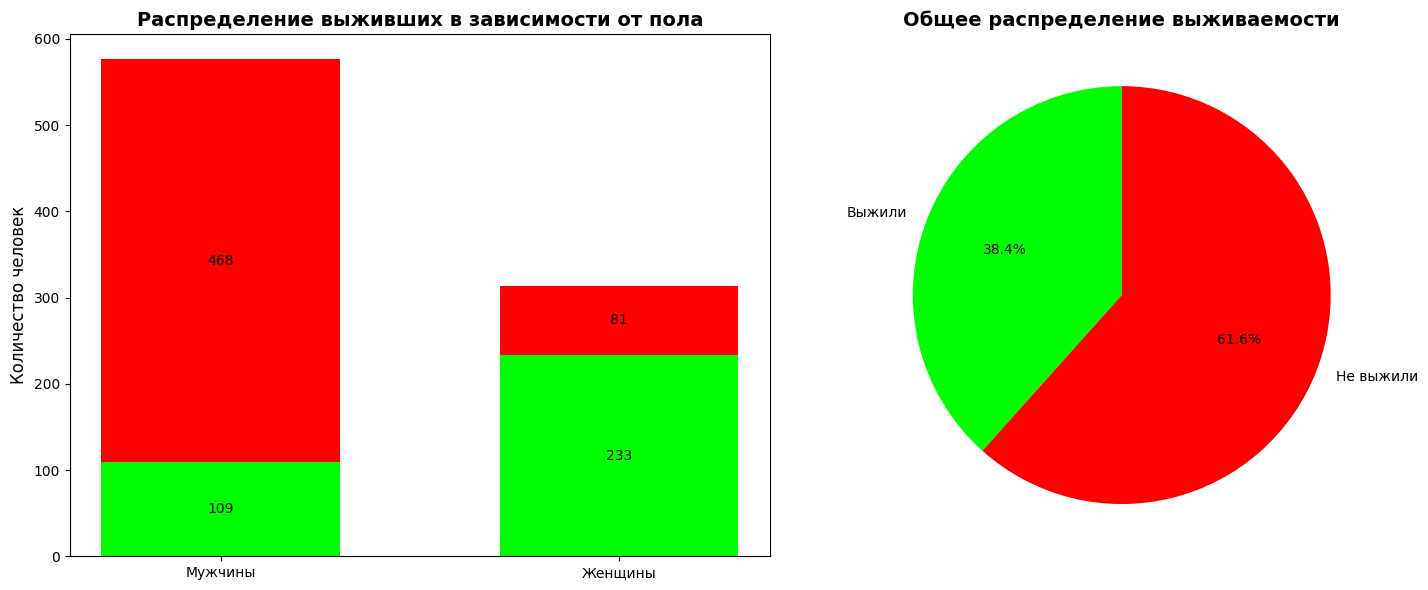


ГИПОТЕЗА: Женщин выжило больше чем мужчин
 ГИПОТЕЗА ПОДТВЕРЖДЕНА
Женщин выжило больше: 233 vs 109


In [11]:
# Гипотеза: женщины выживали чаще мужчин
import numpy as np
import matplotlib.pyplot as plt

# Подсчет 
males_total = len(df.loc[(df['Sex'] == 'male')])
females_total = len(df.loc[(df['Sex'] == 'female')])
males_survived = len(df.loc[(df['Sex'] == 'male') & (df['Survived'] == 1)])
females_survived = len(df.loc[(df['Sex'] == 'female') & (df['Survived'] == 1)])

print(f"Мужчины: всего {males_total}, выжило {males_survived} ({males_survived/males_total*100:.1f}%)")
print(f"Женщины: всего {females_total}, выжило {females_survived} ({females_survived/females_total*100:.1f}%)")


# Визуализация 
survivors_counts = {
    'Выжили': [males_survived, females_survived],
    'Не выжили': [males_total - males_survived, females_total - females_survived]
}
colors_dict = {
    'Выжили': 'lime',
    'Не выжили': 'red'
}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Первый график 
bottom = np.zeros(2)
categories = ['Мужчины', 'Женщины']

for key, count in survivors_counts.items():
    p = ax1.bar(categories, count, width=0.6, label=key, bottom=bottom, color=colors_dict[key])
    ax1.bar_label(p, label_type='center')
    bottom += np.array(count)

ax1.set_title('Распределение выживших в зависимости от пола', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество человек', fontsize=12)

# Второй график 
total_survived = males_survived + females_survived
total_died = (males_total - males_survived) + (females_total - females_survived)

pie_data = [total_survived, total_died]
pie_labels = ['Выжили', 'Не выжили']
pie_colors = ['lime', 'red']

ax2.pie(pie_data, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Общее распределение выживаемости', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Вывод
print("\nГИПОТЕЗА: Женщин выжило больше чем мужчин")
if females_survived > males_survived:
    print(" ГИПОТЕЗА ПОДТВЕРЖДЕНА")
    print(f"Женщин выжило больше: {females_survived} vs {males_survived}")
else:
    print(" ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА")
    print(f"Мужчин выжило больше: {males_survived} vs {females_survived}")


ПРОВЕРКА ГИПОТЕЗЫ: ДЕТИ ВЫЖИВАЛИ ЧАЩЕ
ДЕТИ (до 18 лет):
Всего детей: 113
Выжило детей: 61
Процент выживших детей: 54.0%

ВЗРОСЛЫЕ (18 лет и старше):
Всего взрослых: 601
Выжило взрослых: 229
Процент выживших взрослых: 38.1%


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)


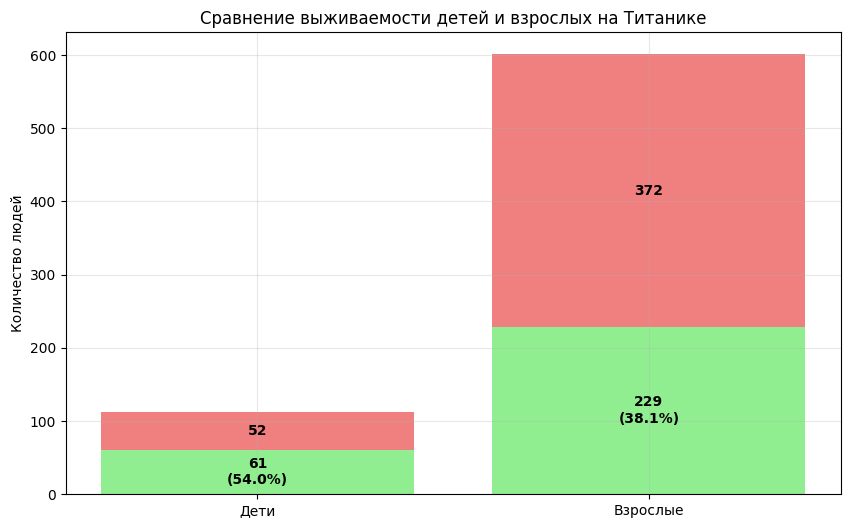


ВЫВОД ПО ГИПОТЕЗЕ:
 ГИПОТЕЗА ПОДТВЕРЖДЕНА
Дети выживали чаще взрослых: 54.0% vs 38.1%


In [12]:
# Гипотеза: дети выживали чаще взрослых

children = df[df['Age'] < 18]
adults = df[df['Age'] >= 18]

print("ПРОВЕРКА ГИПОТЕЗЫ: ДЕТИ ВЫЖИВАЛИ ЧАЩЕ")

# Статистика по детям
children_total = len(children)
children_survived = children['Survived'].sum()
children_survival_rate = children_survived / children_total * 100

# Статистика по взрослым
adults_total = len(adults)
adults_survived = adults['Survived'].sum()
adults_survival_rate = adults_survived / adults_total * 100

print(f"ДЕТИ (до 18 лет):")
print(f"Всего детей: {children_total}")
print(f"Выжило детей: {children_survived}")
print(f"Процент выживших детей: {children_survival_rate:.1f}%")

print(f"\nВЗРОСЛЫЕ (18 лет и старше):")
print(f"Всего взрослых: {adults_total}")
print(f"Выжило взрослых: {adults_survived}")
print(f"Процент выживших взрослых: {adults_survival_rate:.1f}%")

plt.figure(figsize=(10, 6))

# Данные для графика
categories = ['Дети', 'Взрослые']
survived_counts = [children_survived, adults_survived]
total_counts = [children_total, adults_total]

# столбцы выживших
bars1 = plt.bar(categories, survived_counts, color='lightgreen', label='Выжили')

# Рисуем столбцы погибших
bars2 = plt.bar(categories, [children_total-children_survived, adults_total-adults_survived], 
               bottom=survived_counts, color='lightcoral', label='Погибли')

# Подписи 
for i, (survived, total) in enumerate(zip(survived_counts, total_counts)):
    plt.text(i, survived/2, f'{survived}\n({survived/total*100:.1f}%)', 
             ha='center', va='center', fontweight='bold', fontsize=10)
    plt.text(i, survived + (total-survived)/2, f'{total-survived}', 
             ha='center', va='center', fontweight='bold', fontsize=10)

plt.ylabel('Количество людей')
plt.title('Сравнение выживаемости детей и взрослых на Титанике')
plt.grid(True, alpha=0.3)
plt.show()

# Вывод 
print("\nВЫВОД ПО ГИПОТЕЗЕ:")
if children_survival_rate > adults_survival_rate:
    print(" ГИПОТЕЗА ПОДТВЕРЖДЕНА")
    print(f"Дети выживали чаще взрослых: {children_survival_rate:.1f}% vs {adults_survival_rate:.1f}%")
else:
    print(" ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА")
    print(f"Взрослые выживали чаще детей: {adults_survival_rate:.1f}% vs {children_survival_rate:.1f}%")

ВЫЖИВАЕМОСТЬ ПО КЛАССАМ:
Класс 1: 136/216 (63.0%)
Класс 2: 87/184 (47.3%)
Класс 3: 119/491 (24.2%)


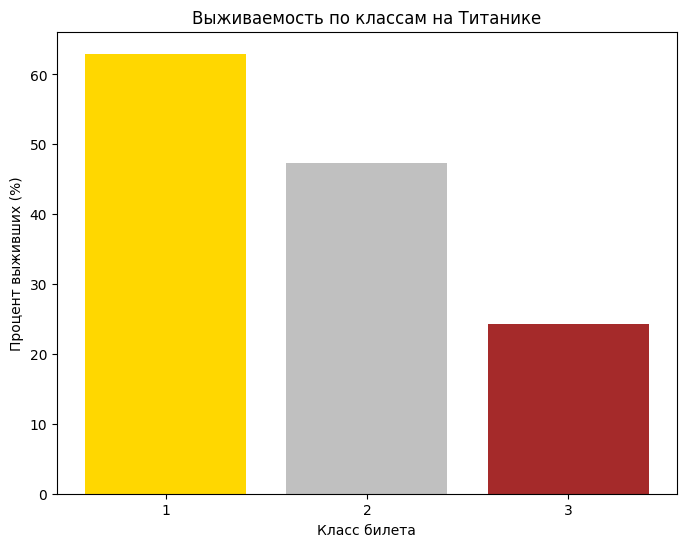

 Гипотеза подтверждена — чем выше класс, тем выше выживаемость.


In [13]:
# Гипотеза: чем лучше класс, тем выше выживаемость
classes = [1, 2, 3]
survival_rates = []

print("ВЫЖИВАЕМОСТЬ ПО КЛАССАМ:")

for pclass in classes:
    class_data = df[df['Pclass'] == pclass]
    total = len(class_data)
    survived = class_data['Survived'].sum()
    rate = survived / total * 100
    survival_rates.append(rate)
    print(f"Класс {pclass}: {survived}/{total} ({rate:.1f}%)")

# Диаграмма
plt.figure(figsize=(8, 6))
plt.bar(classes, survival_rates, color=['gold', 'silver', 'brown'])
plt.xlabel('Класс билета')
plt.ylabel('Процент выживших (%)')
plt.title('Выживаемость по классам на Титанике')
plt.xticks(classes, ['1', '2', '3']) 
plt.show()

# Вывод
if survival_rates[0] > survival_rates[1] > survival_rates[2]:
    print(" Гипотеза подтверждена — чем выше класс, тем выше выживаемость.")
else:
    print(" Гипотеза не подтверждена.")


ВЫЖИВАЕМОСТЬ ПО СТОИМОСТИ БИЛЕТА:
Дешевые (<10): 67/336 (19.9%)
Средние (10-50): 166/394 (42.1%)
Дорогие (50+): 109/161 (67.7%)


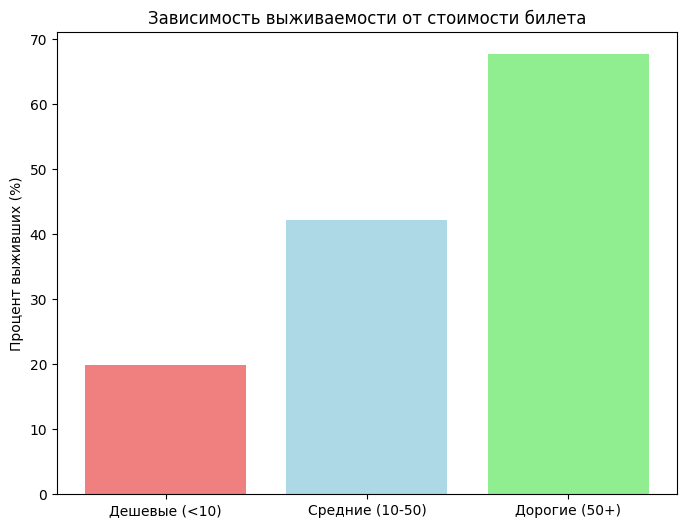

 Гипотеза подтверждена - чем дороже билет, тем выше выживаемость


In [14]:
# Гипотеза: чем дороже билет, тем выше выживаемость
df_no_na = df.dropna(subset=['Fare'])  # Убираем билеты без цены

# Делим на три группы по стоимости билета
low_fare = df_no_na[df_no_na['Fare'] < 10]
medium_fare = df_no_na[(df_no_na['Fare'] >= 10) & (df_no_na['Fare'] < 50)]
high_fare = df_no_na[df_no_na['Fare'] >= 50]

print("ВЫЖИВАЕМОСТЬ ПО СТОИМОСТИ БИЛЕТА:")

fare_groups = [low_fare, medium_fare, high_fare]
group_names = ['Дешевые (<10)', 'Средние (10-50)', 'Дорогие (50+)']
survival_rates = []

for i, group in enumerate(fare_groups):
    total = len(group)
    survived = group['Survived'].sum()
    rate = survived / total * 100
    survival_rates.append(rate)
    print(f"{group_names[i]}: {survived}/{total} ({rate:.1f}%)")

# Диаграмма
plt.figure(figsize=(8, 6))
plt.bar(group_names, survival_rates, color=['lightcoral', 'lightblue', 'lightgreen'])
plt.ylabel('Процент выживших (%)')
plt.title('Зависимость выживаемости от стоимости билета')
plt.xticks
plt.show()

# Вывод
if survival_rates[0] < survival_rates[1] < survival_rates[2]:
    print(" Гипотеза подтверждена - чем дороже билет, тем выше выживаемость")
else:
    print(" Гипотеза не подтверждена")

ВЫЖИВАЕМОСТЬ ПО ПОРТАМ ПОСАДКИ:
Саутгемптон (Англия):
  Выжило: 217/644 (33.7%)
  Погибло: 427/644 (66.3%)

Шербур (Франция):
  Выжило: 93/168 (55.4%)
  Погибло: 75/168 (44.6%)

Квинстаун (Ирландия):
  Выжило: 30/77 (39.0%)
  Погибло: 47/77 (61.0%)



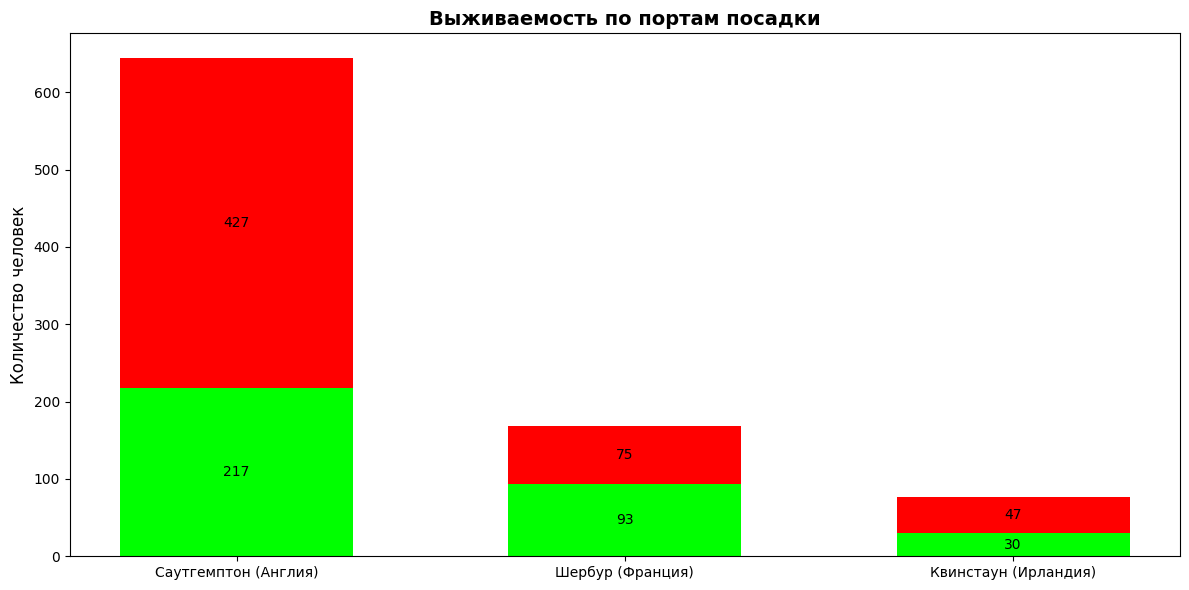

 В каком порту выжило больше людей?
 Из порта Саутгемптон (Англия) выжило 217 человек


In [15]:
# Гипотеза: из какого порта выжило больше людей
ports = ['S', 'C', 'Q']
port_countries = ['Саутгемптон (Англия)', 'Шербур (Франция)', 'Квинстаун (Ирландия)']

print("ВЫЖИВАЕМОСТЬ ПО ПОРТАМ ПОСАДКИ:")

survival_data = []

for i, port in enumerate(ports):
    port_data = df[df['Embarked'] == port]
    total = len(port_data)
    survived = port_data['Survived'].sum()
    died = total - survived
    
    survival_data.append([survived, died])
    
    print(f"{port_countries[i]}:")
    print(f"  Выжило: {survived}/{total} ({survived/total*100:.1f}%)")
    print(f"  Погибло: {died}/{total} ({died/total*100:.1f}%)")
    print()

# Находим порт с максимальной выживаемостью
survived_counts = [data[0] for data in survival_data]
max_survival = max(survived_counts)
best_port_index = survived_counts.index(max_survival)
best_port = port_countries[best_port_index]



# Диаграмма с выжившими и погибшими по портам
fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(3)
colors = ['lime', 'red']

for i, status in enumerate(['Выжили', 'Не выжили']):
    counts = [data[i] for data in survival_data]
    p = ax.bar(port_countries, counts, width=0.6, label=status, bottom=bottom, color=colors[i])
    ax.bar_label(p, label_type='center')
    bottom += np.array(counts)

ax.set_title('Выживаемость по портам посадки', fontsize=14, fontweight='bold')
ax.set_ylabel('Количество человек', fontsize=12)
plt.xticks
plt.tight_layout()
plt.show()
# Вывод:
print(f" В каком порту выжило больше людей?")
print(f" Из порта {best_port} выжило {max_survival} человек")

ВЫЖИВАЕМОСТЬ ЛЮДЕЙ С РОДСТВЕННИКАМИ И БЕЗ:
С родственниками: 179/354 (50.6%)
Без родственников: 163/537 (30.4%)


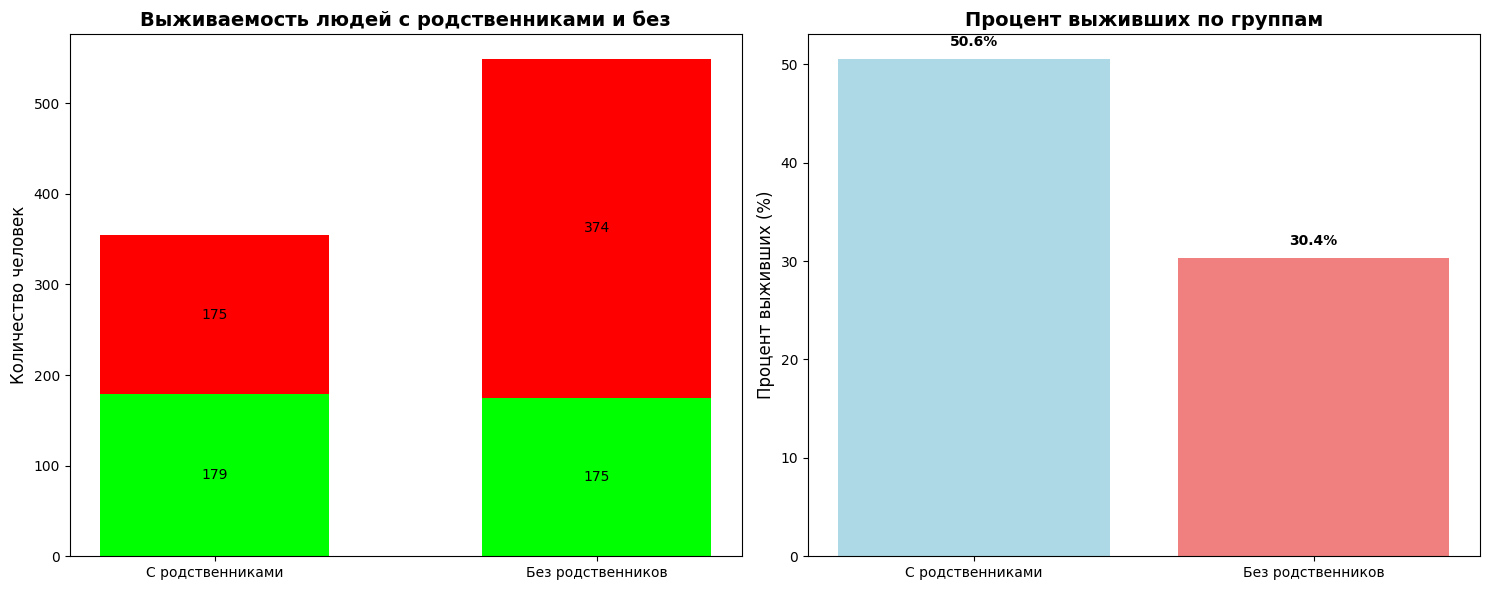


ГИПОТЕЗА: Люди с родственниками умирали чаще
 ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА
Люди с родственниками выживали чаще: 50.6% vs 30.4%


In [16]:
# Гипотеза: люди с родственниками умирали чаще чем одиночки
df['HasFamily'] = (df['SibSp'] + df['Parch']) > 0

print("ВЫЖИВАЕМОСТЬ ЛЮДЕЙ С РОДСТВЕННИКАМИ И БЕЗ:")

# Люди с родственниками
with_family = df[df['HasFamily'] == True]
with_family_total = len(with_family)
with_family_survived = with_family['Survived'].sum()
with_family_rate = with_family_survived / with_family_total * 100

# Люди без родственников
without_family = df[df['HasFamily'] == False]
without_family_total = len(without_family)
without_family_survived = without_family['Survived'].sum()
without_family_rate = without_family_survived / without_family_total * 100

print(f"С родственниками: {with_family_survived}/{with_family_total} ({with_family_rate:.1f}%)")
print(f"Без родственников: {without_family_survived}/{without_family_total} ({without_family_rate:.1f}%)")

# Диаграмма
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Первая диаграмма - столбчатая
categories = ['С родственниками', 'Без родственников']
survived_counts = [with_family_survived, without_family_survived]
died_counts = [with_family_total - with_family_survived, without_family_total - without_family_survived]

bottom = np.zeros(2)
colors = ['lime', 'red']

for i, status in enumerate(['Выжили', 'Не выжили']):
    counts = [survived_counts[i], died_counts[i]] if i == 0 else [died_counts[0], died_counts[1]]
    p = ax1.bar(categories, counts, width=0.6, label=status, bottom=bottom, color=colors[i])
    ax1.bar_label(p, label_type='center')
    bottom += np.array(counts)

ax1.set_title('Выживаемость людей с родственниками и без', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество человек', fontsize=12)


# Вторая диаграмма - проценты
rates = [with_family_rate, without_family_rate]
bars = ax2.bar(categories, rates, color=['lightblue', 'lightcoral'])
ax2.set_ylabel('Процент выживших (%)', fontsize=12)
ax2.set_title('Процент выживших по группам', fontsize=14, fontweight='bold')

# Добавляем проценты на столбцы
for bar, rate in zip(bars, rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 1, f'{rate:.1f}%', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Вывод:
print(f"\nГИПОТЕЗА: Люди с родственниками умирали чаще")
if with_family_rate < without_family_rate:
    print(" ГИПОТЕЗА ПОДТВЕРЖДЕНА")
    print(f"Люди с родственниками выживали реже: {with_family_rate:.1f}% vs {without_family_rate:.1f}%")
else:
    print(" ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА")
    print(f"Люди с родственниками выживали чаще: {with_family_rate:.1f}% vs {without_family_rate:.1f}%")

ВЫЖИВАЕМОСТЬ ПО ВОЗРАСТНЫМ ДИАПАЗОНАМ:
0-20 лет: 82/179 (45.8%)
21-40 лет: 153/385 (39.7%)
41-60 лет: 50/128 (39.1%)
61+ лет: 5/22 (22.7%)


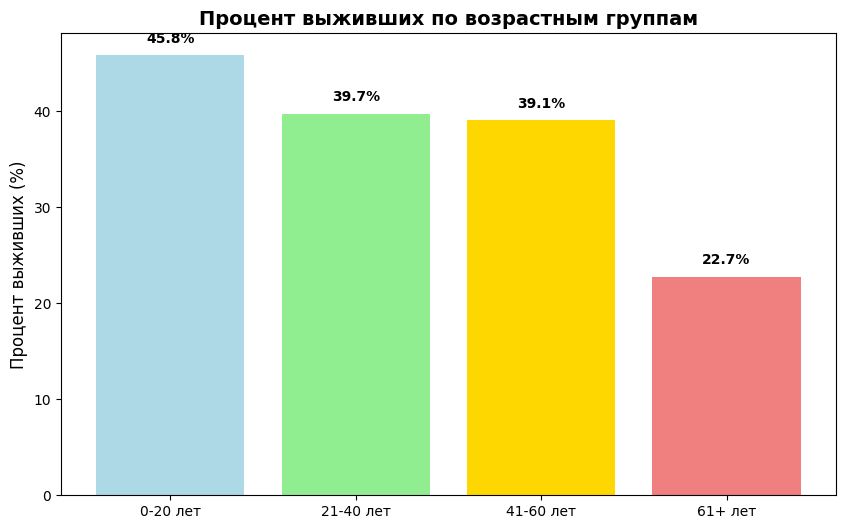


ГИПОТЕЗА: В каком возрастном диапазоне выживали чаще?
 ОТВЕТ: В диапазоне 0-20 лет - 45.8% выживших


In [17]:
# Гипотеза: в каком возрастном диапазоне выживали чаще?

# Делим на диапазоны по 20 лет
age_bins = [0, 20, 40, 60, 100]
age_labels = ['0-20 лет', '21-40 лет', '41-60 лет', '61+ лет']

print("ВЫЖИВАЕМОСТЬ ПО ВОЗРАСТНЫМ ДИАПАЗОНАМ:")

# Создаем возрастные группы
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

survival_rates = []

for age_group in age_labels:
    group_data = df[df['AgeGroup'] == age_group]
    total = len(group_data)
    survived = group_data['Survived'].sum()
    rate = survived / total * 100 if total > 0 else 0
    
    survival_rates.append(rate)
    
    print(f"{age_group}: {survived}/{total} ({rate:.1f}%)")

# Находим диапазон с максимальной выживаемостью
max_rate = max(survival_rates)
best_age_index = survival_rates.index(max_rate)
best_age_group = age_labels[best_age_index]


# Вторая диаграмма - проценты выживаемости
plt.figure(figsize=(10, 6))
bars = plt.bar(age_labels, survival_rates, color=['lightblue', 'lightgreen', 'gold', 'lightcoral'])
plt.ylabel('Процент выживших (%)', fontsize=12)
plt.title('Процент выживших по возрастным группам', fontsize=14, fontweight='bold')

# Добавляем проценты на столбцы
for bar, rate in zip(bars, survival_rates):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{rate:.1f}%', 
             ha='center', va='bottom', fontweight='bold')

plt.show()
    
print(f"\nГИПОТЕЗА: В каком возрастном диапазоне выживали чаще?")
print(f" ОТВЕТ: В диапазоне {best_age_group} - {max_rate:.1f}% выживших")

Корреляция с 'Survived':



Fare           0.257307
HasFamily      0.203367
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

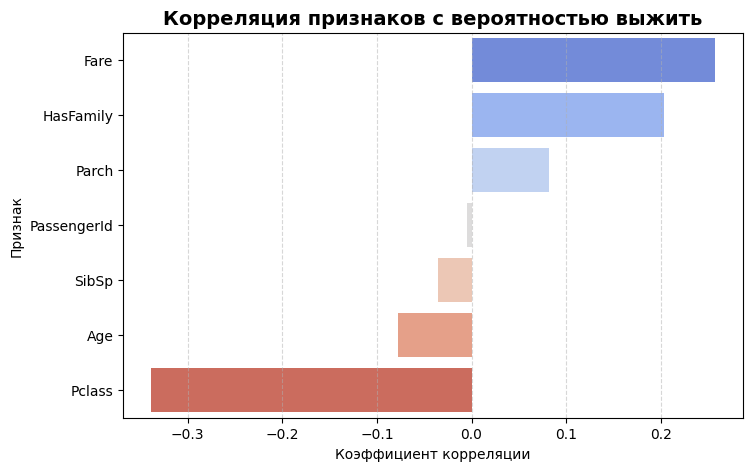


Вывод:
 - Fare (Стоимость билета): корреляция 0.257 → увеличивает вероятность выжить
 - HasFamily (— описание отсутствует —): корреляция 0.203 → увеличивает вероятность выжить
 - Parch (Количество родителей и детей на борту): корреляция 0.082 → увеличивает вероятность выжить
 - PassengerId (Порядковый номер пассажира (технический столбец)): корреляция -0.005 → уменьшает вероятность выжить
 - SibSp (Количество братьев/сестёр и супругов на борту): корреляция -0.035 → уменьшает вероятность выжить
 - Age (Возраст пассажира): корреляция -0.077 → уменьшает вероятность выжить
 - Pclass (Класс билета (1 = лучший, 3 = худший)): корреляция -0.338 → уменьшает вероятность выжить


In [18]:
# Корреляция признаков с выживаемостью 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Расчет корреляций только для числовых столбцов
correlation_with_survived = (
    df.corr(numeric_only=True)['Survived']
    .drop('Survived')
    .sort_values(ascending=False)
)

# 2. Таблица значений
print("Корреляция с 'Survived':\n")
display(correlation_with_survived)

# 3. Визуализация 
plt.figure(figsize=(8, 5))
sns.barplot(
    x=correlation_with_survived.values,
    y=correlation_with_survived.index,
    palette='coolwarm'
)
plt.title('Корреляция признаков с вероятностью выжить', fontsize=14, fontweight='bold')
plt.xlabel('Коэффициент корреляции')
plt.ylabel('Признак')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 4. Расшифровка признаков
feature_descriptions = {
    'Pclass': 'Класс билета (1 = лучший, 3 = худший)',
    'Age': 'Возраст пассажира',
    'SibSp': 'Количество братьев/сестёр и супругов на борту',
    'Parch': 'Количество родителей и детей на борту',
    'Fare': 'Стоимость билета',
    'PassengerId': 'Порядковый номер пассажира (технический столбец)'
}

# 5. вывод
print("\nВывод:")
for feature, corr in correlation_with_survived.items():
    meaning = feature_descriptions.get(feature, '— описание отсутствует —')
    direction = "увеличивает" if corr > 0 else "уменьшает"
    print(f" - {feature} ({meaning}): корреляция {corr:.3f} → {direction} вероятность выжить")




In [14]:
import numpy as np
import pandas as pd

# Инструменты из sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, log_loss

# Загружаю датасет Titanic
df = pd.read_csv('/kaggle/input/titanik/Titanic.csv')

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
print("Размеры датасета:", df.shape)
print("\nРаспределение Survived:")
print(df['Survived'].value_counts())

print("\nПропуски по столбцам:")
print(df.isnull().sum())

print("\nТипы данных:")
print(df.dtypes)


Размеры датасета: (891, 12)

Распределение Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Пропуски по столбцам:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [16]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

df.isnull().sum()


/tmp/ipykernel_38/404126554.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_38/404126554.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [17]:
# Добавляю размер семьи
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Добавляю признак, плывёт ли пассажир один
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Вытаскиваю титул из имени (Mr, Mrs, Miss и т.д.)
df['Title'] = df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

# Привожу похожие титулы к одному виду
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

# Редкие титулы объединяю в одну категорию Rare
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
               'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Превращаю титулы в числовой признак Rank
title_ranks = {
    'Rare': 0,
    'Master': 1,
    'Miss': 2,
    'Mrs': 3,
    'Mr': 4
}

df['Rank'] = df['Title'].map(title_ranks).fillna(0).astype(int)

# Удаляю текстовую колонку Title, она больше не нужна
df = df.drop(columns=['Title'])

df[['Survived', 'FamilySize', 'IsAlone', 'Rank']].head()


,Survived,FamilySize,IsAlone,Rank
0,0,2,0,4
1,1,2,0,3
2,1,1,1,2
3,1,2,0,3
4,0,1,1,4


In [18]:
from sklearn.preprocessing import LabelEncoder

# Нахожу все строковые признаки
categorical_features = df.select_dtypes(include=['object']).columns

label_encoders = {}

# Перевожу каждую категориальную колонку в числа
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Rank
0,1,0,3,108,1,22.0,1,0,523,7.2500,147,2,2,0,4
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0,2,0,3
2,3,1,3,353,0,26.0,0,0,669,7.9250,147,2,1,1,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2,2,0,3
4,5,0,3,15,1,35.0,0,0,472,8.0500,147,2,1,1,4


In [23]:
# Отделяю признаки от целевой переменной
X = df.drop(columns=['Survived'])
y = df['Survived']

# Разделяю данные на обучающие и тестовые
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирую данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Обучаю логистическую регрессию на масштабированных данных
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Предсказываю вероятности и метки
y_pred_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_pred_proba_lr > 0.5).astype(int)

# Считаю accuracy и log-loss
acc_lr = accuracy_score(y_test, y_pred_lr)
ll_lr = log_loss(y_test, y_pred_proba_lr)

acc_lr, ll_lr


(0.8100558659217877, 0.4495272764427571)

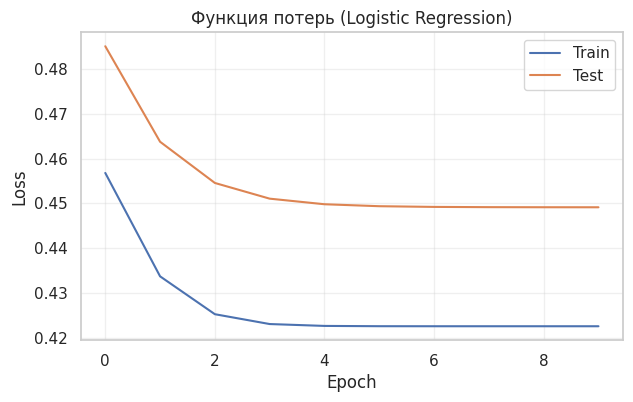

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Функция потерь
epochs_lr = 10   

# Генерирую значения C автоматически
# равномерно в логарифмическом масштабе — как в хорошем ML-подходе
C_values = np.logspace(-2, 2, epochs_lr)  

train_losses_lr = []
test_losses_lr = []

for C in C_values:
    model = LogisticRegression(max_iter=1000, C=C)
    model.fit(X_train_scaled, y_train)
    
    # log-loss на train
    train_proba = model.predict_proba(X_train_scaled)[:, 1]
    train_losses_lr.append(log_loss(y_train, train_proba))
    
    # log-loss на test
    test_proba = model.predict_proba(X_test_scaled)[:, 1]
    test_losses_lr.append(log_loss(y_test, test_proba))

plt.figure(figsize=(7,4))
plt.plot(train_losses_lr, label='Train')
plt.plot(test_losses_lr, label='Test')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Функция потерь (Логистическая регрессия)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




In [31]:
from sklearn.tree import DecisionTreeClassifier

# Обучаю дерево решений на немасштабированных данных
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# Делаю предсказания
y_pred_proba_tree = tree_model.predict_proba(X_test)[:, 1]
y_pred_tree = tree_model.predict(X_test)

# Считаю качество
acc_tree = accuracy_score(y_test, y_pred_tree)
ll_tree = log_loss(y_test, y_pred_proba_tree)

acc_tree, ll_tree


(0.8156424581005587, 0.44822662576462374)

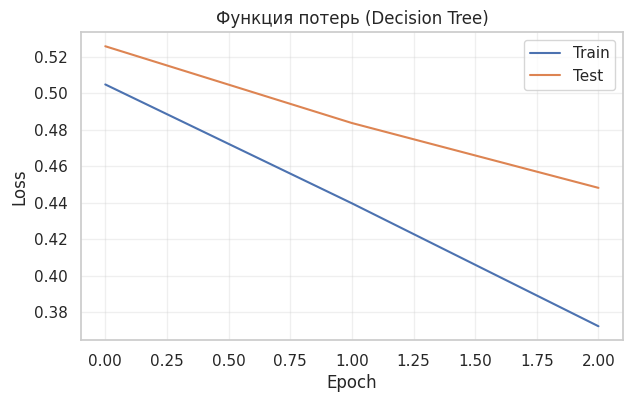

In [64]:
train_losses_tree = []
test_losses_tree = []
depths = range(1, 4)  # разные "сложности" модели

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    # считаю log-loss на train
    train_proba = model.predict_proba(X_train)[:, 1]
    train_losses_tree.append(log_loss(y_train, train_proba))
    
    # считаю log-loss на test
    test_proba = model.predict_proba(X_test)[:, 1]
    test_losses_tree.append(log_loss(y_test, test_proba))

plt.figure(figsize=(7,4))
plt.plot(train_losses_tree, label='Train')
plt.plot(test_losses_tree, label='Test')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Функция потерь (Decision Tree)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [42]:
from xgboost import XGBClassifier

# Количество эпох для бустинга 
epochs_xgb = 60  

# Обучаю модель градиентного бустинга XGBoost
xgb_model = XGBClassifier(
    n_estimators=epochs_xgb,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# Предсказания и метрики XGBoost
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_pred_proba_xgb > 0.5).astype(int)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
ll_xgb = log_loss(y_test, y_pred_proba_xgb)

# Сохраняю историю обучения для графика
results_xgb = xgb_model.evals_result()

acc_xgb, ll_xgb


(0.7877094972067039, 0.45576910007633714)

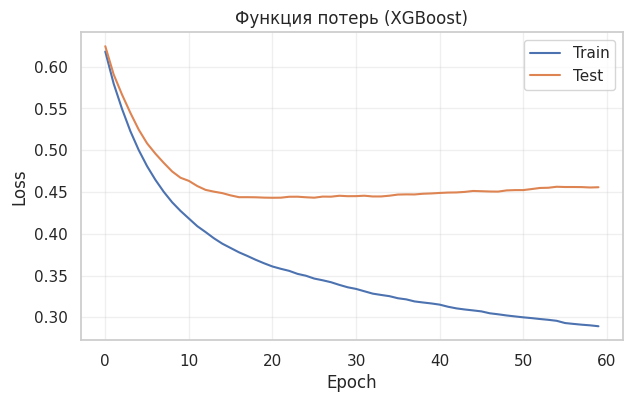

In [43]:
# Достаю значения функции потерь из истории обучения
train_loss_xgb = results_xgb['validation_0']['logloss']
test_loss_xgb = results_xgb['validation_1']['logloss']

plt.figure(figsize=(7,4))
plt.plot(train_loss_xgb, label='Train')
plt.plot(test_loss_xgb, label='Test')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Функция потерь (XGBoost)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Количество эпох для нейросети
epochs_nn = 10  

# Строю простую полносвязную нейросеть
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Компилирую модель
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Обучаю модель и сохраняю историю обучения
history = model.fit(
    X_train_scaled, y_train,
    epochs=epochs_nn,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Оцениваю качество на тестовой выборке
test_loss_nn, test_acc_nn = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc_nn:.4f}")
print(f"Test Loss: {test_loss_nn:.4f}")


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4538 - loss: 0.7481 - val_accuracy: 0.5874 - val_loss: 0.6614
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6770 - loss: 0.6273 - val_accuracy: 0.7063 - val_loss: 0.5951
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7430 - loss: 0.5600 - val_accuracy: 0.7413 - val_loss: 0.5536
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7798 - loss: 0.5055 - val_accuracy: 0.7692 - val_loss: 0.5210
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7902 - loss: 0.4778 - val_accuracy: 0.7972 - val_loss: 0.4990
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7993 - loss: 0.4621 - val_accuracy: 0.8112 - val_loss: 0.4851
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8429 - loss: 0.4052 - val_accuracy: 0.8252 - val_loss: 0.4764
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8368 - loss: 0.4129 - val_accuracy: 0.8112 - val_loss: 0.4706
Ep

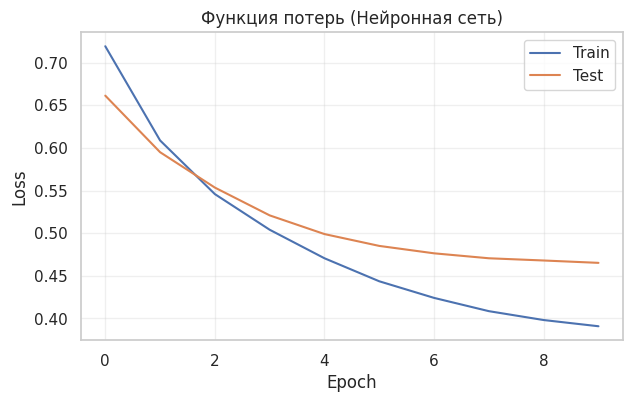

In [63]:
plt.figure(figsize=(7,4))

# Потери на обучении и валидации по эпохам
train_loss_nn = history.history['loss']
val_loss_nn = history.history['val_loss']

plt.plot(train_loss_nn, label='Train')
plt.plot(val_loss_nn, label='Test')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Функция потерь (Нейронная сеть)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [46]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

# Здесь я заново беру полный X и y для кросс-валидации
X_full = df.drop(columns=['Survived'])
y_full = df['Survived']

# Стратифицированная кросс-валидация на 5 фолдов
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Здесь я задаю три модели для сравнения
models = {
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'DecisionTree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=60,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42
    )
}

results_cv = {}

for name, model in models.items():
    # Здесь я считаю accuracy по 5 фолдам
    scores = cross_val_score(model, X_full, y_full, cv=cv, scoring='accuracy')
    results_cv[name] = scores
    print(name, "CV accuracy:", scores.mean().round(4), "±", scores.std().round(4))


LogisticRegression CV accuracy: 0.8092 ± 0.0204
DecisionTree CV accuracy: 0.8036 ± 0.0288
XGBoost CV accuracy: 0.826 ± 0.0155


In [47]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Полные данные
X_full = df.drop(columns=['Survived'])
y_full = df['Survived'].values

# Кросс-валидация
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Лучшая модель — XGBoost
best_model = XGBClassifier(
    n_estimators=60,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

# Массив для out-of-fold предсказаний
oof_preds = np.zeros(len(X_full))

for train_idx, valid_idx in kf.split(X_full, y_full):
    X_train_cv, X_valid_cv = X_full.iloc[train_idx], X_full.iloc[valid_idx]
    y_train_cv, y_valid_cv = y_full[train_idx], y_full[valid_idx]

    best_model.fit(X_train_cv, y_train_cv)
    preds = best_model.predict_proba(X_valid_cv)[:, 1]
    oof_preds[valid_idx] = preds

# Переводим вероятности в метки
oof_labels = (oof_preds > 0.5).astype(int)

# Находим ошибки
errors_idx = np.where(oof_labels != y_full)[0]

len(errors_idx)


155

In [48]:
errors_df = df.iloc[errors_idx].copy()
errors_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Rank
10,11,1,3,727,0,4.0,1,1,616,16.7000,145,2,3,0,2
14,15,0,3,840,0,14.0,0,0,413,7.8542,147,2,1,1,2
17,18,1,2,867,1,28.0,0,0,151,13.0000,147,2,1,1,4
18,19,0,3,839,0,31.0,1,0,301,18.0000,147,2,2,0,3
23,24,1,1,765,1,28.0,0,0,42,35.5000,13,2,1,1,4


In [49]:
print("Ошибки по полу:")
print(errors_df['Sex'].value_counts(normalize=True))

print("\nОшибки по классу:")
print(errors_df['Pclass'].value_counts(normalize=True))

print("\nОшибки по возрасту (среднее):")
print(errors_df['Age'].mean().round(2))


Ошибки по полу:
Sex
1    0.6
0    0.4
Name: proportion, dtype: float64

Ошибки по классу:
Pclass
3    0.574194
1    0.341935
2    0.083871
Name: proportion, dtype: float64

Ошибки по возрасту (среднее):
30.53


In [52]:
correct_idx = np.where(oof_labels == y_full)[0]
correct_df = df.iloc[correct_idx]

print("Средний возраст правильных предсказаний:", correct_df['Age'].mean().round(2))
print("Средний возраст ошибочных предсказаний:", errors_df['Age'].mean().round(2))

print("\nРаспределение пола у правильных предсказаний:")
print(correct_df['Sex'].value_counts(normalize=True))

print("\nРаспределение пола у ошибочных предсказаний:")
print(errors_df['Sex'].value_counts(normalize=True))


Средний возраст правильных предсказаний: 29.12
Средний возраст ошибочных предсказаний: 30.53

Распределение пола у правильных предсказаний:
Sex
1    0.657609
0    0.342391
Name: proportion, dtype: float64

Распределение пола у ошибочных предсказаний:
Sex
1    0.6
0    0.4
Name: proportion, dtype: float64


In [62]:
import pandas as pd

results_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'XGBoost', 'Neural Network'],
    'Accuracy': [
        acc_lr,
        acc_tree,
        acc_xgb,
        test_acc_nn
    ],
    'Log-loss': [
        ll_lr,
        ll_tree,
        ll_xgb,
        test_loss_nn
    ]
})

results_table


,Model,Accuracy,Log-loss
0,Logistic Regression,0.810056,0.449527
1,Decision Tree,0.815642,0.448227
2,XGBoost,0.787709,0.455769
3,Neural Network,0.793296,0.470355


In [67]:
conclusion = """
Итоговый вывод по моделям:

В результате сравнения четырёх моделей — логистической регрессии, Decision Tree, XGBoost и нейронной сети — лучше всего показало себя Decision Tree,
дав самое высокое значение accuracy и минимальный log-loss.

Логистическая регрессия показала стабильный результат, немного уступив Decision Tree.

XGBoost оказался слабее остальных.

Нейронная сеть показала средний результат и уступила классическим методам, что ожидаемо для маленького табличного датасета.
"""

print(conclusion)



Итоговый вывод по моделям:

В результате сравнения четырёх моделей — логистической регрессии, Decision Tree, XGBoost и нейронной сети — лучше всего показало себя Decision Tree,
дав самое высокое значение accuracy и минимальный log-loss.

Логистическая регрессия показала стабильный результат, немного уступив Decision Tree.

XGBoost оказался слабее остальных.

Нейронная сеть показала средний результат и уступила классическим методам, что ожидаемо для маленького табличного датасета.

